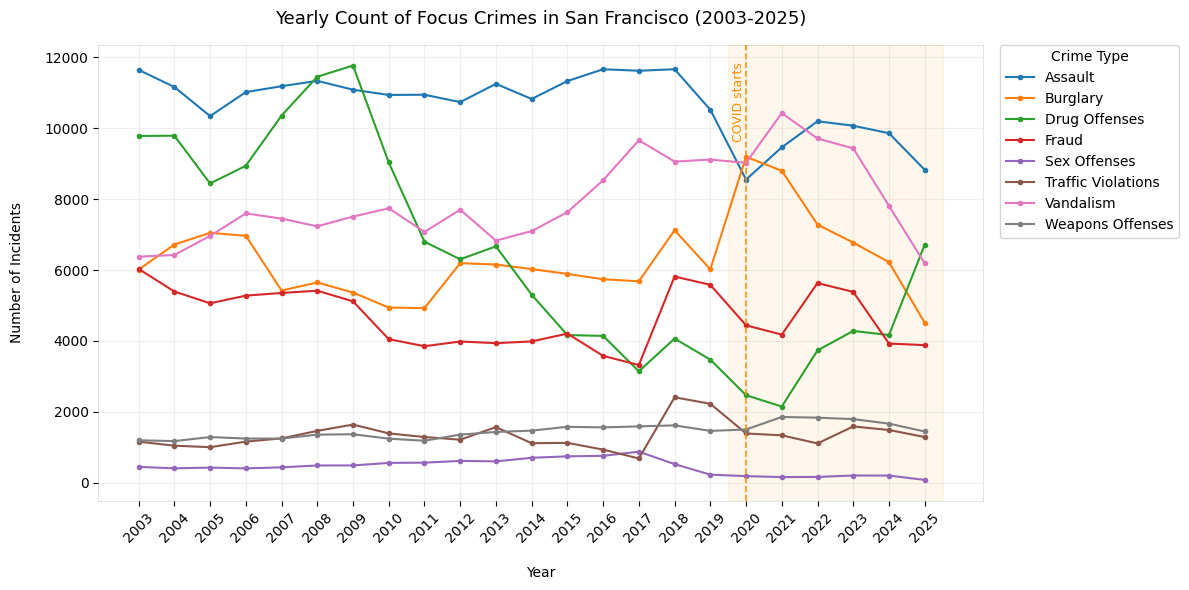

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

focus_data = pd.read_csv('Data/merged_focus_crime_data.csv', parse_dates=['Date'])
category_display_map = {
    'assault': 'Assault',
    'burglary': 'Burglary',
    'drug': 'Drug Offenses',
    'fraud': 'Fraud',
    'sex offenses': 'Sex Offenses',
    'traffic': 'Traffic Violations',
    'vandalism': 'Vandalism',
    'weapons': 'Weapons Offenses',
}
original_category = focus_data['Standardized_Category']
focus_data['Standardized_Category'] = (
    original_category.astype('string').str.strip().str.lower().map(category_display_map).fillna(original_category)
)
focus_data['Year'] = focus_data['Date'].dt.year
focus_data = focus_data[focus_data['Year'] < 2026]
yearly_counts = focus_data.groupby(['Year', 'Standardized_Category']).size().unstack(fill_value=0)
yearly_counts.plot(kind='line', marker='.', figsize=(12,6))
plt.title("Yearly Count of Focus Crimes in San Francisco (2003-2025)", pad=15, fontsize=13)
# axis labels and ticks
plt.xlabel("Year", labelpad=15)
plt.ylabel("Number of Incidents", labelpad=15)
plt.xticks(yearly_counts.index, rotation=45)

plt.legend(
    title="Crime Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

# grid & opacity
plt.grid()
plt.grid(alpha=0.2)

# lighter frame
ax = plt.gca()
covid_start = 2020
ax.axvspan(covid_start - 0.5, yearly_counts.index.max() + 0.5, color='orange', alpha=0.08, label='COVID period (2020+)')
ax.axvline(covid_start, color='darkorange', linestyle='--', linewidth=1.2, alpha=0.9)
ax.text(covid_start - 0.02, ax.get_ylim()[1] * 0.96, 'COVID starts', color='darkorange', fontsize=9, rotation=90, ha='right', va='top')
for spine in ax.spines.values():
    spine.set_alpha(0.1)

plt.tight_layout()
plt.show()


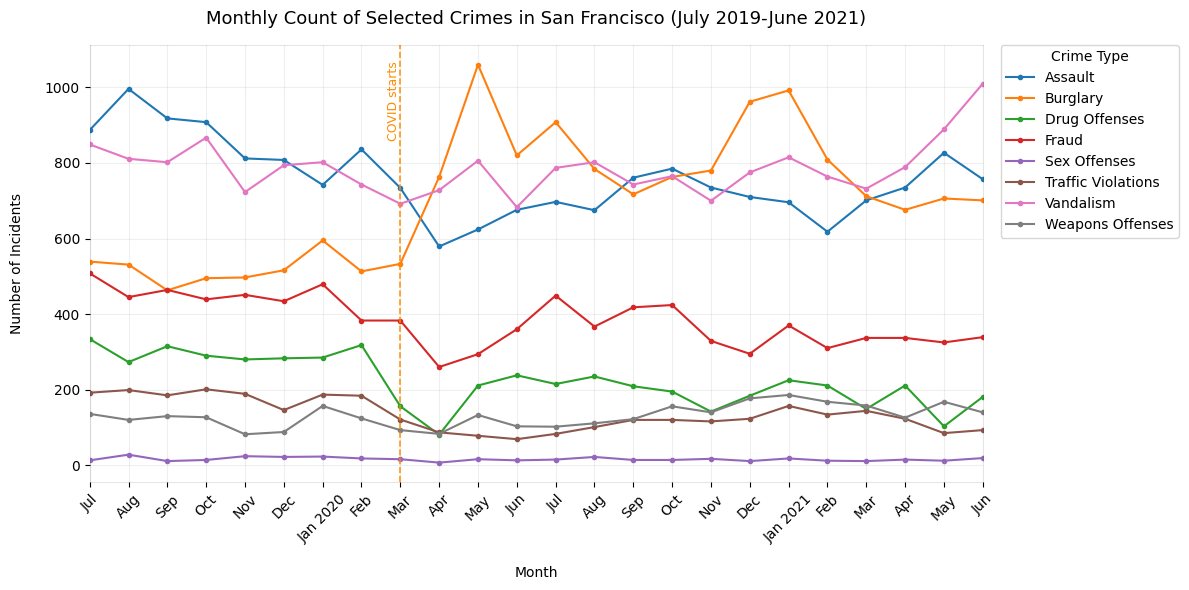

In [7]:
monthly_data = focus_data[focus_data['Year'].between(2019, 2021)].copy()
monthly_data['YearMonth'] = monthly_data['Date'].dt.to_period('M').dt.to_timestamp()
monthly_counts = monthly_data.groupby(['YearMonth', 'Standardized_Category']).size().unstack(fill_value=0)
full_month_index = pd.date_range('2019-07-01', '2021-06-01', freq='MS')
monthly_counts = monthly_counts.reindex(full_month_index, fill_value=0)

monthly_counts.plot(kind='line', marker='.', figsize=(12, 6))
plt.title("Monthly Count of Selected Crimes in San Francisco (July 2019-June 2021)", pad=15, fontsize=13)
plt.xlabel("Month", labelpad=15)
plt.ylabel("Number of Incidents", labelpad=15)
month_labels = [d.strftime('%b %Y') if d.month == 1 else d.strftime('%b') for d in monthly_counts.index]
plt.xticks(monthly_counts.index, month_labels, rotation=45)

plt.legend(
    title="Crime Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.grid()
plt.grid(alpha=0.2)

ax = plt.gca()
covid_start_month = pd.Timestamp('2020-03-01')
ax.axvline(covid_start_month, color='darkorange', linestyle='--', linewidth=1.2, alpha=0.9)
ax.text(covid_start_month, ax.get_ylim()[1] * 0.96, 'COVID starts', color='darkorange', fontsize=9, rotation=90, ha='right', va='top')
for spine in ax.spines.values():
    spine.set_alpha(0.1)

plt.tight_layout()
plt.savefig('visualizations/monthly_crimes_covid.svg', dpi=72)
plt.show()
